# 第5节：对抗攻击原理与生成方法（FGSM / PGD / CW）

本节目标：

1. 理解对抗样本：在扰动约束下让模型输出发生错误（或定向到指定类别）
2. 明确白盒 vs 黑盒：
   - 白盒：可访问模型结构/参数/梯度
   - 黑盒：只能查询输出（或完全不知），常用迁移攻击/查询攻击
3. 掌握并实现主流攻击：
   - FGSM（单步梯度符号）
   - PGD（多步迭代+投影，常用最强一阶基线）
   - CW（Carlini & Wagner，优化式攻击；本节提供教学版实现）
4. 实验输出：
   - 干净准确率 vs 攻击后准确率
   - 不同 ε（L∞ 约束）下的鲁棒曲线
   - 对抗样本可视化：原图/扰动/对抗图


## 0. 路径与环境约定

统一使用：

```python
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
```

本节默认：
- 若 data/ 下存在 `digits.npz`（X,y）或 `X.npy`+`y.npy`，优先用本地数据
- 否则回退 sklearn digits（8×8 灰度，10 分类）

模型：PyTorch 小型 MLP（CPU 可跑）。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)
print('torch:', torch.__version__, 'cuda available:', torch.cuda.is_available())

device = torch.device('cpu')


CWD: /Users/jairo_wu/Documents/File/博士/课程/人工智能安全/实操
PROJECT_ROOT: /Users/jairo_wu/Documents/File/博士/课程/人工智能安全
DATA_DIR exists: True | /Users/jairo_wu/Documents/File/博士/课程/人工智能安全/data
torch: 2.0.1 cuda available: False


## 1. 数据加载与预处理

我们把输入归一化到 `[0,1]`，便于定义扰动范围（ε）。

- digits 回退数据原始范围大致在 `[0,16]`
- 本地数据若已是 `[0,1]` 也可自动兼容


In [2]:
def load_course_data():
    npz_path = DATA_DIR / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path}'

    x_npy = DATA_DIR / 'X.npy'
    y_npy = DATA_DIR / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)  # (n, 64)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data()
print(info)
print('X:', X.shape, X.dtype, 'y:', y.shape, y.dtype)

# 归一化到 [0,1]
x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

print('range:', float(X01.min()), float(X01.max()))


Loaded local NPZ: C:\Users\wingl\PycharmProjects\adversarialmeow\data\digits.npz
X: (1797, 64) float32 y: (1797,) int64
range: 0.0 1.0


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X01, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

print('train:', X_train_t.shape, y_train_t.shape)
print('test :', X_test_t.shape, y_test_t.shape)


train: torch.Size([1347, 64]) torch.Size([1347])
test : torch.Size([450, 64]) torch.Size([450])


### 可视化几张样本（digits 为 8×8）

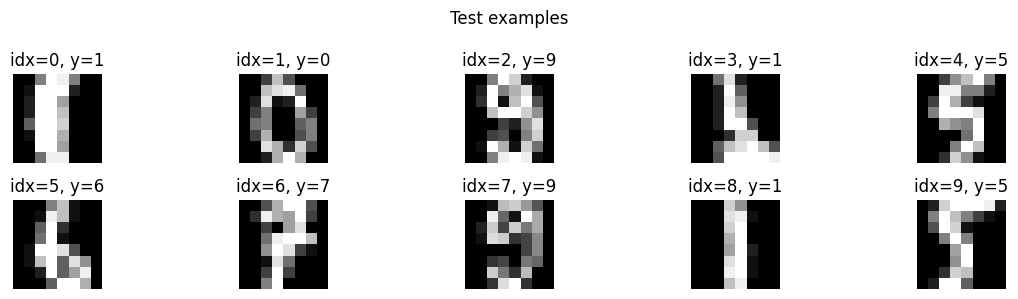

In [4]:
def show_samples(Xflat, y, idxs, title='samples'):
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(idxs):
        ax = plt.subplot(2, len(idxs)//2 + len(idxs)%2, i+1)
        ax.imshow(Xflat[idx].reshape(8, 8), cmap='gray')
        ax.set_title(f'idx={idx}, y={int(y[idx])}')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(X_test, y_test, list(range(10)), title='Test examples')


## 2. 训练一个基线模型（白盒攻击目标模型）

这里用一个小型 MLP：
- 输入 64 维
- 两层隐藏层
- 输出 10 类

训练目标：交叉熵。

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim=64, hidden=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def accuracy(model, X, y, batch=256):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            yb = y[i:i+batch]
            pred = model(xb).argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(len(xb))
    return correct / max(total, 1)

model = MLP().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_model(model, X, y, epochs=10, batch=256):
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb = X[idx]
            yb = y[idx]
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            acc_tr = accuracy(model, X, y)
            acc_te = accuracy(model, X_test_t, y_test_t)
            print(f'Epoch {ep:02d} | train acc={acc_tr:.4f} | test acc={acc_te:.4f}')

train_model(model, X_train_t, y_train_t, epochs=12)

print('Final clean test acc:', accuracy(model, X_test_t, y_test_t))


Epoch 01 | train acc=0.4588 | test acc=0.4356
Epoch 02 | train acc=0.6748 | test acc=0.6600
Epoch 04 | train acc=0.8575 | test acc=0.8333
Epoch 06 | train acc=0.8827 | test acc=0.8489
Epoch 08 | train acc=0.8983 | test acc=0.8511
Epoch 10 | train acc=0.9094 | test acc=0.8822
Epoch 12 | train acc=0.9235 | test acc=0.8933
Final clean test acc: 0.8933333333333333


## 3. 对抗样本：基本定义与扰动约束

给定输入 x、真实标签 y：
- **非定向攻击（untargeted）**：让模型预测 ≠ y
- **定向攻击（targeted）**：让模型预测 = y_target

常用扰动约束：
- L∞：每个像素的最大改变量 ≤ ε（最常用）

我们统一将输入限定在 `[0,1]`，并在攻击中执行：
- clamp 到 `[0,1]`
- PGD 每步后投影到 L∞ 球：x_adv ∈ [x-ε, x+ε]


## 4. 白盒攻击实现

### 4.1 FGSM（Fast Gradient Sign Method）

核心：
- 计算损失对输入的梯度 ∇x L
- 单步更新：x_adv = x + ε * sign(∇x L)

非定向攻击：增大损失
定向攻击：减小目标类损失（或等价地：对目标损失取负号）

In [6]:
def fgsm_attack(model, x, y, eps=0.1, targeted=False, y_target=None):
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)

    if targeted:
        assert y_target is not None
        loss = F.cross_entropy(logits, y_target)
        # 定向：最小化目标损失 => 梯度下降方向
        grad_sign = torch.sign(torch.autograd.grad(loss, x_adv)[0])
        x_adv = x_adv - eps * grad_sign
    else:
        loss = F.cross_entropy(logits, y)
        grad_sign = torch.sign(torch.autograd.grad(loss, x_adv)[0])
        x_adv = x_adv + eps * grad_sign

    x_adv = torch.clamp(x_adv, 0.0, 1.0).detach()
    return x_adv


### 4.2 PGD（Projected Gradient Descent）

PGD 是 FGSM 的多步版本：
- 每步走一个小步长 α
- 每步后把结果投影回 L∞ 球（相对原始 x）
- 常用随机初始化（random start）提升强度


In [7]:
def pgd_attack(model, x, y, eps=0.1, alpha=0.02, steps=20, random_start=True,
               targeted=False, y_target=None):
    model.eval()
    x_orig = x.detach()
    x_adv = x_orig.clone()

    if random_start:
        x_adv = x_adv + torch.empty_like(x_adv).uniform_(-eps, eps)
        x_adv = torch.clamp(x_adv, 0.0, 1.0)

    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)

        if targeted:
            assert y_target is not None
            loss = F.cross_entropy(logits, y_target)
            grad = torch.autograd.grad(loss, x_adv)[0]
            x_adv = x_adv - alpha * torch.sign(grad)
        else:
            loss = F.cross_entropy(logits, y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            x_adv = x_adv + alpha * torch.sign(grad)

        # 投影到 L∞ 球
        x_adv = torch.max(torch.min(x_adv, x_orig + eps), x_orig - eps)
        x_adv = torch.clamp(x_adv, 0.0, 1.0).detach()

    return x_adv


### 4.3 CW（Carlini & Wagner）教学版实现（L2 优化式）

CW 的核心思路：把“找扰动”变成一个优化问题：
- 目标：最小化扰动大小（常用 L2）
- 同时让模型满足攻击条件（使目标类得分超过其它类）

本节给一个 CPU 可跑的教学版：
- 用可导的变量 w，通过 tanh 映射到 [0,1]
- 优化：||x_adv-x||_2^2 + c * f(x_adv)
- f 用 logits margin 近似

注意：这是教学版，不包含完整的二分搜索 c（简化为固定 c）。

In [8]:
def cw_l2_attack(model, x, y, c=2.0, kappa=0.0, lr=0.02, steps=300, targeted=False, y_target=None):
    """CW L2 教学版（小数据集可跑）。
    x: (B, D) in [0,1]
    """
    model.eval()
    x0 = x.detach()

    # tanh-space: x = 0.5*(tanh(w)+1)
    # 反求 w0：w0 = arctanh(2x-1)
    eps = 1e-6
    x_clamped = torch.clamp(x0, eps, 1 - eps)
    w = torch.atanh(2 * x_clamped - 1).detach().clone().requires_grad_(True)

    opt = torch.optim.Adam([w], lr=lr)

    if targeted:
        assert y_target is not None

    def f(logits, y_true, y_tgt=None):
        # margin-based loss
        # untargeted: max(logit_true - max_other, -kappa)
        # targeted  : max(max_other - logit_target, -kappa)
        B = logits.shape[0]
        if targeted:
            tgt = y_tgt
            logit_t = logits[torch.arange(B), tgt]
            mask = torch.ones_like(logits, dtype=torch.bool)
            mask[torch.arange(B), tgt] = False
            max_other = logits.masked_fill(~mask, -1e9).max(dim=1).values
            return torch.clamp(max_other - logit_t + kappa, min=0.0)
        else:
            logit_y = logits[torch.arange(B), y_true]
            mask = torch.ones_like(logits, dtype=torch.bool)
            mask[torch.arange(B), y_true] = False
            max_other = logits.masked_fill(~mask, -1e9).max(dim=1).values
            return torch.clamp(logit_y - max_other + kappa, min=0.0)

    for i in range(steps):
        x_adv = 0.5 * (torch.tanh(w) + 1.0)
        logits = model(x_adv)
        l2 = ((x_adv - x0) ** 2).sum(dim=1)
        if targeted:
            loss_f = f(logits, y, y_tgt=y_target)
        else:
            loss_f = f(logits, y)
        loss = (l2 + c * loss_f).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if (i+1) % 50 == 0 or i == 0:
            with torch.no_grad():
                pred = logits.argmax(dim=1)
                if targeted:
                    success = float((pred == y_target).float().mean().item())
                else:
                    success = float((pred != y).float().mean().item())
                print(f'CW step {i+1:03d} | loss={loss.item():.4f} | success={success:.3f}')

    x_adv = 0.5 * (torch.tanh(w) + 1.0)
    return x_adv.detach()


## 5. 评估工具：攻击后准确率、成功率、可视化

- 攻击成功率（untargeted）：pred != y
- 攻击成功率（targeted）：pred == y_target


In [9]:
def eval_under_attack(model, X, y, attack_fn, batch=256, **attack_kwargs):
    model.eval()
    total = 0
    correct = 0
    success = 0

    targeted = bool(attack_kwargs.get('targeted', False))

    with torch.no_grad():
        pred_clean = model(X).argmax(dim=1)
    clean_acc = float((pred_clean == y).float().mean().item())

    for i in range(0, len(X), batch):
        xb = X[i:i+batch]
        yb = y[i:i+batch]

        # 生成对抗样本需要梯度，因此不能包在 no_grad
        x_adv = attack_fn(model, xb, yb, **attack_kwargs)

        with torch.no_grad():
            pred_adv = model(x_adv).argmax(dim=1)
            correct += int((pred_adv == yb).sum().item())
            total += int(len(xb))

            if targeted:
                y_target = attack_kwargs['y_target'][i:i+batch]
                success += int((pred_adv == y_target).sum().item())
            else:
                success += int((pred_adv != yb).sum().item())

    adv_acc = correct / max(total, 1)
    succ_rate = success / max(total, 1)
    return clean_acc, adv_acc, succ_rate

def visualize_attack(model, x, y, x_adv, title='attack'):
    model.eval()
    with torch.no_grad():
        p0 = model(x).argmax(dim=1).cpu().numpy()
        p1 = model(x_adv).argmax(dim=1).cpu().numpy()

    x0 = x.cpu().numpy()
    xa = x_adv.cpu().numpy()
    perturb = xa - x0

    B = min(6, len(x0))
    plt.figure(figsize=(12, 6))
    for i in range(B):
        ax1 = plt.subplot(3, B, i+1)
        ax1.imshow(x0[i].reshape(8, 8), cmap='gray')
        ax1.set_title(f'orig y={int(y[i])} p={int(p0[i])}')
        ax1.axis('off')

        ax2 = plt.subplot(3, B, B+i+1)
        ax2.imshow(perturb[i].reshape(8, 8), cmap='gray')
        ax2.set_title('perturb')
        ax2.axis('off')

        ax3 = plt.subplot(3, B, 2*B+i+1)
        ax3.imshow(xa[i].reshape(8, 8), cmap='gray')
        ax3.set_title(f'adv p={int(p1[i])}')
        ax3.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## 6. FGSM 实验：不同 ε 下的鲁棒性曲线

FGSM eps=0.020 | clean=0.8933 | adv_acc=0.8644 | succ=0.1356
FGSM eps=0.050 | clean=0.8933 | adv_acc=0.7800 | succ=0.2200
FGSM eps=0.080 | clean=0.8933 | adv_acc=0.6533 | succ=0.3467
FGSM eps=0.100 | clean=0.8933 | adv_acc=0.5600 | succ=0.4400
FGSM eps=0.150 | clean=0.8933 | adv_acc=0.2844 | succ=0.7156
FGSM eps=0.200 | clean=0.8933 | adv_acc=0.0956 | succ=0.9044


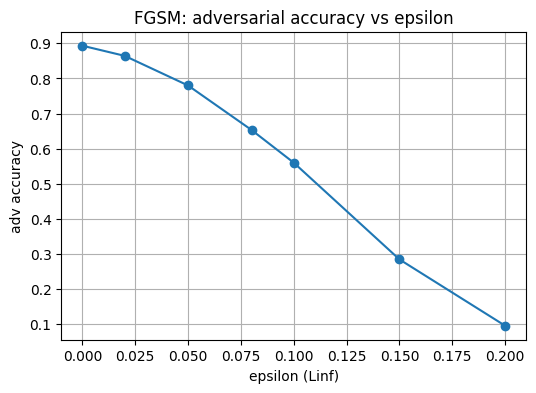

In [19]:
eps_list = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
results = []

for eps in eps_list:
    if eps == 0.0:
        clean_acc = accuracy(model, X_test_t, y_test_t)
        results.append((eps, clean_acc, clean_acc, 0.0))
        continue

    c_acc, a_acc, succ = eval_under_attack(
            model, X_test_t, y_test_t,
            attack_fn=fgsm_attack,
            eps=eps,
            targeted=False
        )
    results.append((eps, c_acc, a_acc, succ))
    print(f'FGSM eps={eps:.3f} | clean={c_acc:.4f} | adv_acc={a_acc:.4f} | succ={succ:.4f}')

eps_arr = [r[0] for r in results]
adv_acc_arr = [r[2] for r in results]

plt.figure(figsize=(6,4))
plt.plot(eps_arr, adv_acc_arr, marker='o')
plt.title('FGSM: adversarial accuracy vs epsilon')
plt.xlabel('epsilon (Linf)')
plt.ylabel('adv accuracy')
plt.grid(True)
plt.show()


### FGSM 可视化（取一批样本）

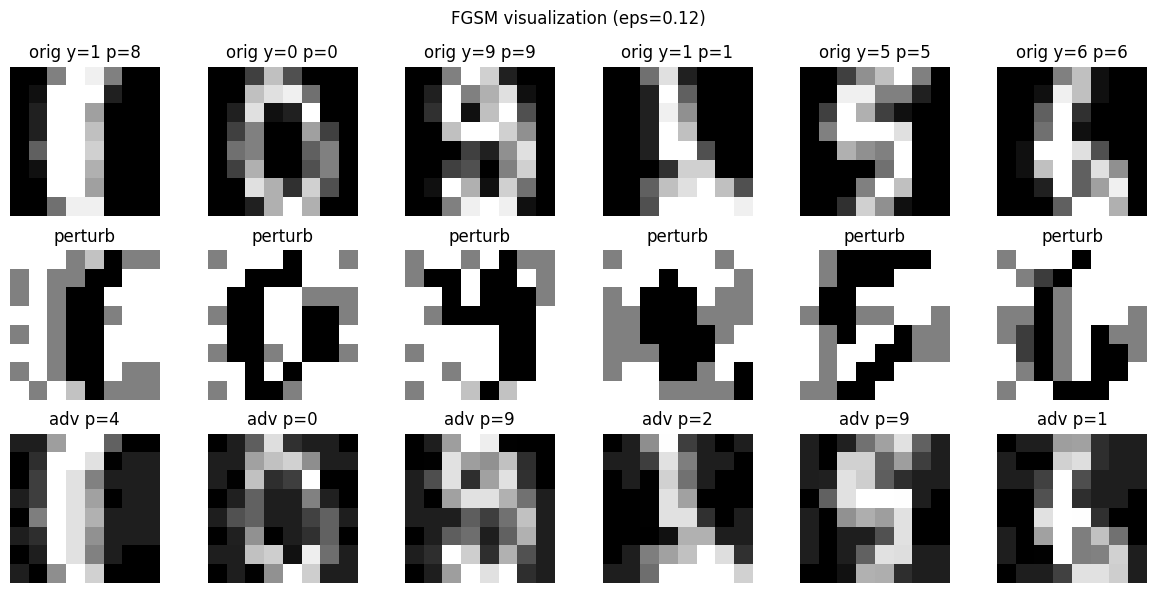

In [12]:
idxs = torch.arange(0, 12, device=device)
x0 = X_test_t[idxs]
y0 = y_test_t[idxs]

eps = 0.12
x_adv = fgsm_attack(model, x0, y0, eps=eps)
visualize_attack(model, x0, y0.cpu().numpy(), x_adv, title=f'FGSM visualization (eps={eps})')


## 7. PGD 实验：更强的迭代攻击

PGD 常被作为“一阶最强基线”。
- ε：扰动上限
- α：每步步长（常取 ε/steps 的量级）
- steps：迭代步数

我们对比 FGSM vs PGD：同一 ε 下 PGD 通常更强。

PGD eps=0.120 alpha=0.020 steps=20 | clean=0.8933 | adv_acc=0.4422 | succ=0.5578


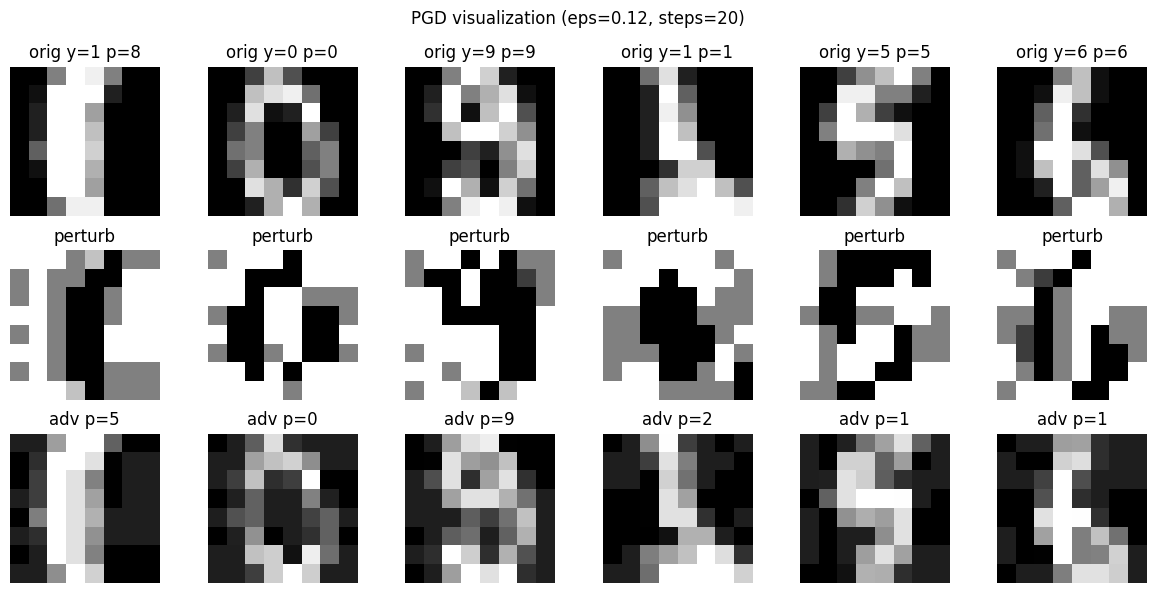

In [17]:
eps = 0.12
alpha = 0.02
steps = 20

c_acc, a_acc, succ = eval_under_attack(
    model, X_test_t, y_test_t,
    attack_fn=pgd_attack,
    eps=eps, alpha=alpha, steps=steps, random_start=True,
    targeted=False
)

print(f'PGD eps={eps:.3f} alpha={alpha:.3f} steps={steps} | clean={c_acc:.4f} | adv_acc={a_acc:.4f} | succ={succ:.4f}')

idxs = torch.arange(0, 12, device=device)
x0 = X_test_t[idxs]
y0 = y_test_t[idxs]
x_adv = pgd_attack(model, x0, y0, eps=eps, alpha=alpha, steps=steps, random_start=True)
visualize_attack(model, x0, y0.cpu().numpy(), x_adv, title=f'PGD visualization (eps={eps}, steps={steps})')


## 8. CW 实验（教学版）：优化式攻击

CW 一般比 FGSM/PGD 更“精细”，常在较小扰动下实现攻击。
为了课堂可跑，我们仅对一个小 batch 做示范。

提示：CW 参数含义（教学直觉）：
- c：让攻击目标成立的“力度”
- steps：优化步数（越多越强但更慢）
- kappa：margin（越大越要求强攻击）


CW step 001 | loss=7.1963 | success=0.062
CW step 050 | loss=0.9807 | success=0.688
CW step 100 | loss=0.7637 | success=0.938
CW step 150 | loss=0.6636 | success=0.812
CW step 200 | loss=0.5528 | success=0.688
CW step 250 | loss=0.4521 | success=0.938
CW demo batch success: 0.8125
Mean L2 perturbation: 0.6096646189689636


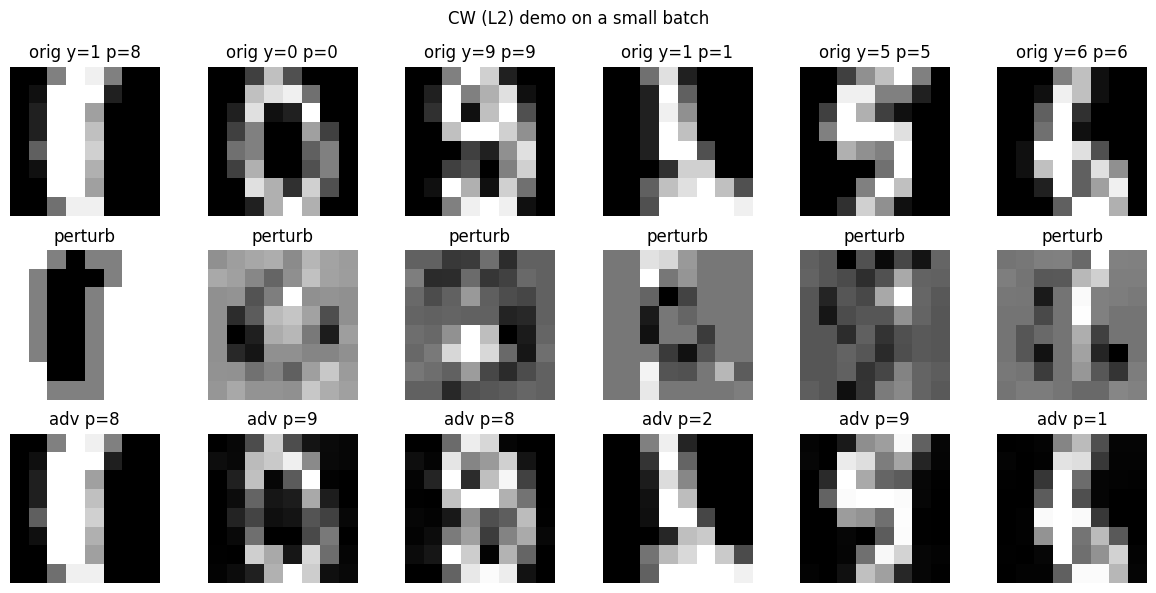

In [14]:
idxs = torch.arange(0, 16, device=device)
x0 = X_test_t[idxs]
y0 = y_test_t[idxs]

x_adv = cw_l2_attack(model, x0, y0, c=3.0, kappa=0.0, lr=0.03, steps=250, targeted=False)

with torch.no_grad():
    p0 = model(x0).argmax(dim=1)
    p1 = model(x_adv).argmax(dim=1)
    succ = float((p1 != y0).float().mean().item())
    l2 = torch.sqrt(((x_adv - x0) ** 2).sum(dim=1)).mean().item()

print('CW demo batch success:', succ)
print('Mean L2 perturbation:', l2)

visualize_attack(model, x0, y0.cpu().numpy(), x_adv, title='CW (L2) demo on a small batch')


## 9. 黑盒攻击：迁移攻击（Transfer Attack）演示

黑盒场景下，攻击者可能拿不到目标模型梯度。
常见思路：训练一个**替代模型（surrogate）**，在替代模型上做白盒攻击，
再把对抗样本拿去攻击目标模型——这就是迁移攻击。

本节演示：
- 目标模型：model（上面训练好的）
- 替代模型：surrogate（结构不同/初始化不同）
- 在 surrogate 上做 PGD，然后评估在 target（model）上的攻击成功率


In [15]:
surrogate = MLP(hidden=64).to(device)
opt_s = torch.optim.Adam(surrogate.parameters(), lr=1e-3)

def train_surrogate(model_s, X, y, epochs=10, batch=256):
    for ep in range(1, epochs+1):
        model_s.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb = X[idx]
            yb = y[idx]
            logits = model_s(xb)
            loss = F.cross_entropy(logits, yb)
            opt_s.zero_grad()
            loss.backward()
            opt_s.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            acc_tr = accuracy(model_s, X, y)
            acc_te = accuracy(model_s, X_test_t, y_test_t)
            print(f'[surrogate] Epoch {ep:02d} | train acc={acc_tr:.4f} | test acc={acc_te:.4f}')

train_surrogate(surrogate, X_train_t, y_train_t, epochs=10)

print('Target clean acc    :', accuracy(model, X_test_t, y_test_t))
print('Surrogate clean acc :', accuracy(surrogate, X_test_t, y_test_t))


[surrogate] Epoch 01 | train acc=0.2346 | test acc=0.2244
[surrogate] Epoch 02 | train acc=0.3653 | test acc=0.3333
[surrogate] Epoch 04 | train acc=0.5805 | test acc=0.5489
[surrogate] Epoch 06 | train acc=0.6689 | test acc=0.6578
[surrogate] Epoch 08 | train acc=0.7253 | test acc=0.7156
[surrogate] Epoch 10 | train acc=0.7854 | test acc=0.7533
Target clean acc    : 0.8933333333333333
Surrogate clean acc : 0.7533333333333333


In [16]:
def transfer_pgd(surrogate, target, X, y, eps=0.10, alpha=0.02, steps=20, batch=256):
    surrogate.eval()
    target.eval()

    total = 0
    success_on_target = 0
    adv_acc_on_target = 0
    clean_acc_on_target = accuracy(target, X, y)

    for i in range(0, len(X), batch):
        xb = X[i:i+batch]
        yb = y[i:i+batch]
        x_adv = pgd_attack(surrogate, xb, yb, eps=eps, alpha=alpha, steps=steps, random_start=True)
        with torch.no_grad():
            pred_t = target(x_adv).argmax(dim=1)
            adv_acc_on_target += int((pred_t == yb).sum().item())
            success_on_target += int((pred_t != yb).sum().item())
            total += int(len(xb))

    adv_acc = adv_acc_on_target / max(total, 1)
    succ = success_on_target / max(total, 1)
    return clean_acc_on_target, adv_acc, succ

eps = 0.10
alpha = 0.02
steps = 20

c_acc, a_acc, succ = transfer_pgd(surrogate, model, X_test_t, y_test_t, eps=eps, alpha=alpha, steps=steps)
print(f'Transfer PGD (surrogate->target) eps={eps} steps={steps} | target clean={c_acc:.4f} | target adv_acc={a_acc:.4f} | succ={succ:.4f}')


Transfer PGD (surrogate->target) eps=0.1 steps=20 | target clean=0.8933 | target adv_acc=0.7044 | succ=0.2956


## 10. 本节小结

1. FGSM：一次梯度符号更新，快但通常弱于迭代攻击。
2. PGD：多步迭代 + 投影，是最常用的一阶强攻击基线。
3. CW：优化式攻击，常能以更小扰动达成攻击（但更慢，参数更敏感）。
4. 黑盒迁移：用替代模型生成对抗样本，依赖“迁移性”攻击目标。

下一节可衔接：
- 对抗训练与防御（输入变换/检测/拒识/鲁棒训练）
- 更真实的黑盒：查询限制、得分不可见、随机化防御


## 11. 练习

1) FGSM 与 PGD：在相同 ε 下比较攻击后准确率，解释差异。

2) PGD 超参数：固定 ε，改变 steps/alpha，画出攻击强度变化曲线。

3) CW：调 c 与 steps，观察成功率与平均扰动 L2 的变化。

4) 迁移攻击：
- 换不同 surrogate 结构（更小/更大），迁移成功率是否变化？
- surrogate 精度越高是否一定迁移更强？为什么？
